# ANALYSIS

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from pathlib import Path

In [8]:
BASE_DIR = Path('/scratch/saporito/Frag3D')
FINAL_STEP = 'step_36533'
MASS_THRESHOLD = 1e-6

SIM_FOLDERS = [
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_1.5e-02_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_1.5e-02_1.5e-02',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_2.5e-02_2.5e-02',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy3.0e+01_thz3.0e+01_sgn1.0e+00_cntr_1.5e-02_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy6.0e+01_thz0.0e+00_sgn1.0e+00_cntr_1.5e-02_0.0e+00',
]

def make_label(folder: str) -> str:
    m_thxy = re.search(r'thxy([^_]+)', folder)
    m_thz  = re.search(r'thz([^_]+)',  folder)
    m_cntr = re.search(r'cntr_([0-9.e+\-]+)_([0-9.e+\-]+)', folder)
    thxy   = float(m_thxy.group(1)) if m_thxy else 0
    thz    = float(m_thz.group(1))  if m_thz  else 0
    cx, cy = (float(m_cntr.group(1)), float(m_cntr.group(2))) if m_cntr else (0, 0)
    return f'thxy={thxy:.0f}° thz={thz:.0f}° | cntr=({cx:.2g},{cy:.2g})'

LABELS = [make_label(f) for f in SIM_FOLDERS]
COLORS = plt.cm.tab10(np.linspace(0, 0.5, len(SIM_FOLDERS)))

print('Simulation labels:')
for i, lbl in enumerate(LABELS):
    print(f'  [{i}] {lbl}')

Simulation labels:
  [0] thxy=0° thz=0° | cntr=(0.015,0)
  [1] thxy=0° thz=0° | cntr=(0.015,0.015)
  [2] thxy=0° thz=0° | cntr=(0.025,0.025)
  [3] thxy=30° thz=30° | cntr=(0.015,0)
  [4] thxy=60° thz=0° | cntr=(0.015,0)


## 1 - Load final-step data for all simulations

In [9]:
SCALAR_ATTRS = ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'total_energy', 'work']

scalar_rows = []
fragment_data = {}

for folder, label in zip(SIM_FOLDERS, LABELS):
    h5path = BASE_DIR / folder / 'data.h5'
    with h5py.File(h5path, 'r') as f:
        step = f[FINAL_STEP]

        row = {'sim': label}
        for attr in SCALAR_ATTRS:
            row[attr] = float(step.attrs[attr])
        masses = step['fragment_mass'][:]
        vels   = step['fragment_velocity'][:]

        row['nb_fragments_heavy'] = int((masses >= MASS_THRESHOLD).sum())
        scalar_rows.append(row)

        vmag = np.linalg.norm(vels, axis=1)
        fragment_data[label] = {
            'mass':   masses,
            'vmag':   vmag,
            'vx':     vels[:, 0],
            'vy':     vels[:, 1],
            'vz':     vels[:, 2],
        }

print('Done loading', len(scalar_rows), 'simulations.')

Done loading 5 simulations.


## 2 - Energetics table

In [10]:
df_scalar = pd.DataFrame(scalar_rows).set_index('sim')

col_order = ['econ', 'edis', 'ekin', 'epot', 'erev', 'total_energy', 'work',
             'nb_fragments', 'nb_fragments_heavy']
df_scalar = df_scalar[col_order]

col_names = {
    'econ':               'E_con',
    'edis':               'E_dis',
    'ekin':               'E_kin',
    'epot':               'E_pot',
    'erev':               'E_rev',
    'total_energy':       'E_tot',
    'work':               'Work',
    'nb_fragments':       'N_frags',
    'nb_fragments_heavy': f'N_frags (m≥{MASS_THRESHOLD:.0e})',
}
df_display = df_scalar.rename(columns=col_names)

pd.set_option('display.float_format', '{:.4e}'.format)
pd.set_option('display.max_colwidth', None)
display(df_display)

,E_con,E_dis,E_kin,E_pot,E_rev,E_tot,Work,N_frags,N_frags (m≥1e-06)
sim,,,,,,,,,
"thxy=0° thz=0° | cntr=(0.015,0)",0.0000e+00,8.2071e-02,8.6383e+01,1.9558e-01,1.5378e-04,8.6661e+01,0.0000e+00,6.6268e+04,153
"thxy=0° thz=0° | cntr=(0.015,0.015)",0.0000e+00,7.3294e-02,8.6182e+01,1.7839e-01,1.0093e-04,8.6433e+01,0.0000e+00,6.2876e+04,90
"thxy=0° thz=0° | cntr=(0.025,0.025)",0.0000e+00,2.1697e-02,2.1647e+01,5.3522e-02,3.4254e-05,2.1722e+01,0.0000e+00,1.7660e+04,30
"thxy=30° thz=30° | cntr=(0.015,0)",0.0000e+00,8.9194e-02,8.6395e+01,2.1912e-01,1.0824e-04,8.6704e+01,0.0000e+00,7.6079e+04,147
"thxy=60° thz=0° | cntr=(0.015,0)",0.0000e+00,9.4798e-02,8.6397e+01,2.3256e-01,1.1031e-04,8.6724e+01,0.0000e+00,8.2393e+04,159


## 3 - Fragment statistics table  
mean / max / min / std of mass, |v|, vx, vy, vz

In [12]:
FRAG_KEYS   = ['mass', 'vmag', 'vx', 'vy', 'vz']
FRAG_LABELS = ['Mass', '|v|', 'vx', 'vy', 'vz']
STAT_FUNCS  = {'mean': np.mean, 'min': np.min, 'max': np.max, 'std': np.std}

rows = []
idx  = []
for label in LABELS:
    fd = fragment_data[label]
    for key, name in zip(FRAG_KEYS, FRAG_LABELS):
        arr = fd[key]
        row = {stat: fn(arr) for stat, fn in STAT_FUNCS.items()}
        rows.append(row)
        idx.append((label, name))

df_stats = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(idx, names=['sim', 'quantity']))
display(df_stats)

mean         min  \
sim                                 quantity                          
thxy=0° thz=0° | cntr=(0.015,0)     Mass     2.1613e-07  2.8490e-09   
                                    |v|      3.2525e+02  4.5372e-01   
                                    vx       1.2867e-01 -5.6895e+01   
                                    vy       2.2940e-02 -4.0523e+01   
                                    vz       3.2462e+02 -3.1825e+01   
thxy=0° thz=0° | cntr=(0.015,0.015) Mass     2.2805e-07  2.3528e-09   
                                    |v|      3.4383e+02  2.5810e-01   
                                    vx       5.7049e-02 -4.2154e+01   
                                    vy       8.1519e-02 -4.6762e+01   
                                    vz       3.4330e+02 -3.0616e+01   
thxy=0° thz=0° | cntr=(0.025,0.025) Mass     9.0081e-07  3.2247e-09   
                                    |v|      3.0472e+02  2.3816e-01   
                                    vx       1.2922e-01 -4.6433e+01   
                                    vy       1.5446e-01 -3.8213e+01   
                                    vz       3.0408e+02 -1.6851e+01   
thxy=30° thz=30° | cntr=(0.015,0)   Mass     1.8396e-07  2.8490e-09   
                                    |v|      2.9251e+02  5.9932e-01   
                                    vx       1.4546e+02 -5.1712e+01   
                                    vy       1.2593e+02 -3.6201e+01   
                                    vz       2.1929e+02 -2.5075e+01   
thxy=60° thz=0° | cntr=(0.015,0)    Mass     1.6919e-07  2.7644e-09   
                                    |v|      2.7459e+02  6.0426e-01   
                                    vx       5.0309e-02 -5.4217e+01   
                                    vy       2.3675e+02 -3.4453e+01   
                                    vz       1.3730e+02 -4.3805e+01   

                                                    max        std  
sim                                 quantity                        
thxy=0° thz=0° | cntr=(0.015,0)     Mass     3.8329e-03 2.5813e-05  
                                    |v|      1.0122e+03 2.6680e+02  
                                    vx       5.4529e+01 7.1552e+00  
                                    vy       8.1928e+01 7.3341e+00  
                                    vz       1.0118e+03 2.6737e+02  
thxy=0° thz=0° | cntr=(0.015,0.015) Mass     4.0961e-03 2.8306e-05  
                                    |v|      1.0168e+03 2.6494e+02  
                                    vx       4.6993e+01 7.1744e+00  
                                    vy       6.1220e+01 7.2553e+00  
                                    vz       1.0166e+03 2.6542e+02  
thxy=0° thz=0° | cntr=(0.025,0.025) Mass     5.0812e-03 6.6224e-05  
                                    |v|      1.0481e+03 2.6095e+02  
                                    vx       4.6738e+01 7.3274e+00  
                                    vy       4.4429e+01 7.1889e+00  
                                    vz       1.0474e+03 2.6150e+02  
thxy=30° thz=30° | cntr=(0.015,0)   Mass     3.7790e-03 2.3743e-05  
                                    |v|      1.0070e+03 2.6301e+02  
                                    vx       5.1562e+02 1.3231e+02  
                                    vy       4.4522e+02 1.1475e+02  
                                    vz       7.5954e+02 1.9739e+02  
thxy=60° thz=0° | cntr=(0.015,0)    Mass     3.7721e-03 2.2770e-05  
                                    |v|      1.0119e+03 2.6166e+02  
                                    vx       5.1768e+01 6.1845e+00  
                                    vy       8.8503e+02 2.2754e+02  
                                    vz       5.2398e+02 1.3095e+02

## 4 - Distribution plots

In [15]:
from scipy.stats import gaussian_kde


def kde_line(ax, arr, color, label, log_x=False, bw_method='scott'):
    """Draw a single KDE curve on ax."""
    data = arr[arr > 0] if log_x else arr
    if len(data) < 2:
        return
    if log_x:
        log_data = np.log10(data)
        kde = gaussian_kde(log_data, bw_method=bw_method)
        xs_log = np.linspace(log_data.min(), log_data.max(), 500)
        ys = kde(xs_log) / np.log(10)          # Jacobian for log10 axis
        xs = 10 ** xs_log
    else:
        kde = gaussian_kde(data, bw_method=bw_method)
        xs = np.linspace(data.min(), data.max(), 500)
        ys = kde(xs)
    ax.plot(xs, ys, color=color, label=label, linewidth=1.8)
    ax.fill_between(xs, ys, alpha=0.12, color=color)


def plot_kde_combined(frag_data, labels, colors, key, xlabel, log_x=False):
    """All sims on one axes."""
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, color in zip(labels, colors):
        kde_line(ax, frag_data[label][key], color, label, log_x)
    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Probability density', fontsize=11)
    ax.set_title(f'Distribution of {xlabel} — all configs', fontsize=12)
    ax.legend(fontsize=7, framealpha=0.5)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
    plt.tight_layout()
    plt.show()


def plot_kde_individual(frag_data, labels, colors, key, xlabel, log_x=False):
    """One subplot per sim, shared axes for easy comparison."""
    n = len(labels)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
    # Compute global x range across all sims for a consistent x axis
    all_data = [frag_data[lbl][key] for lbl in labels]
    if log_x:
        xmin = min(a[a > 0].min() for a in all_data)
        xmax = max(a.max() for a in all_data)
    else:
        xmin = min(a.min() for a in all_data)
        xmax = max(a.max() for a in all_data)

    for ax, label, color in zip(axes, labels, colors):
        kde_line(ax, frag_data[label][key], color, label=None, log_x=log_x)
        if log_x:
            ax.set_xscale('log')
            ax.set_xlim(xmin, xmax)
        else:
            ax.set_xlim(xmin, xmax)
        ax.set_title(label, fontsize=8, wrap=True)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))

    axes[0].set_ylabel('Probability density', fontsize=10)
    fig.suptitle(f'Distribution of {xlabel} — individual configs', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


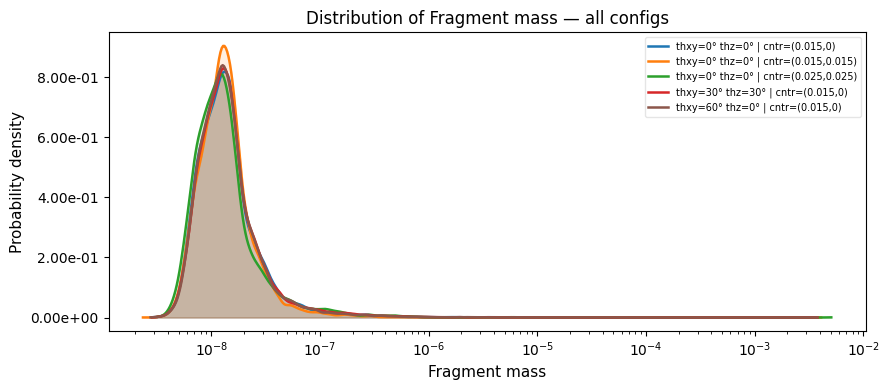

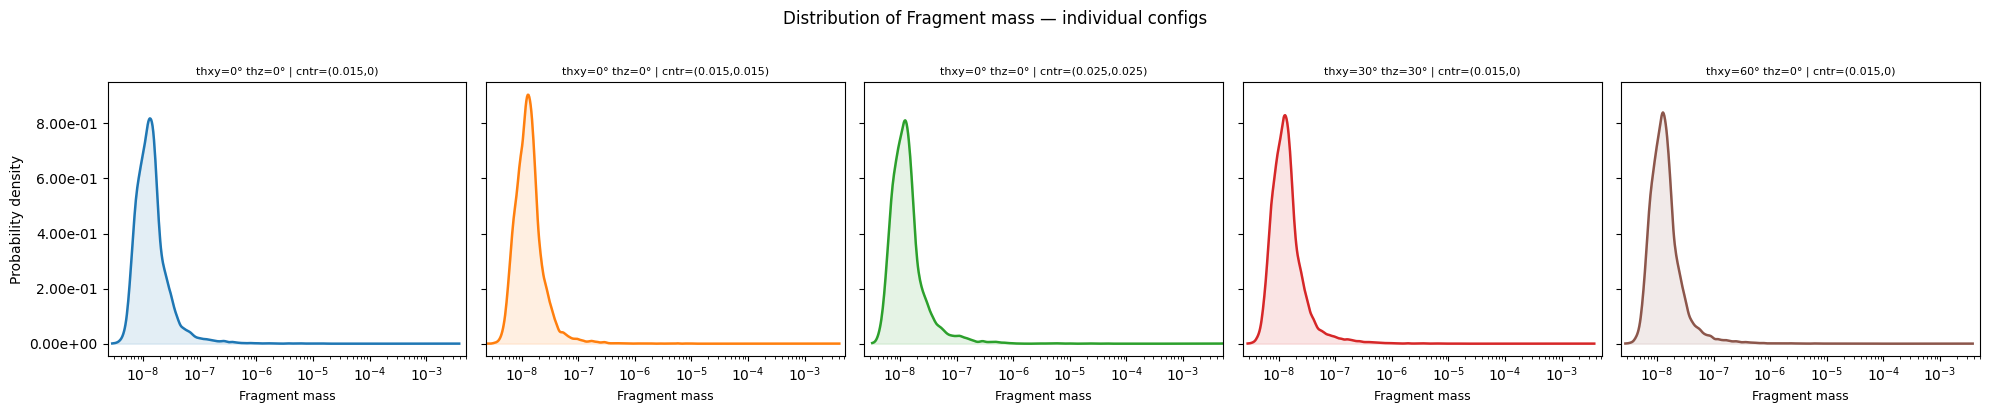

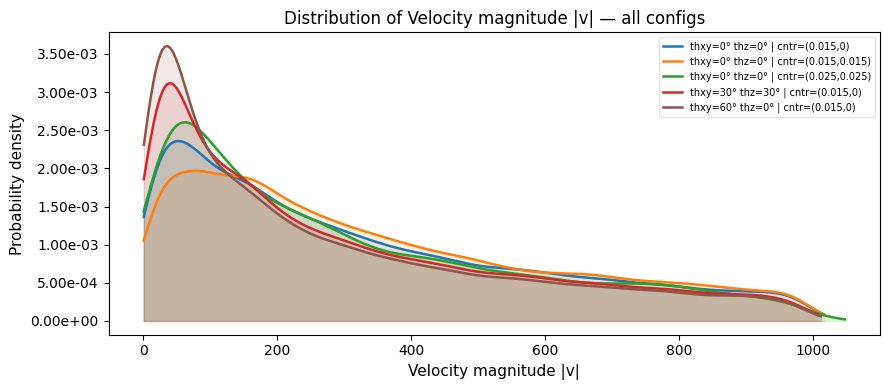

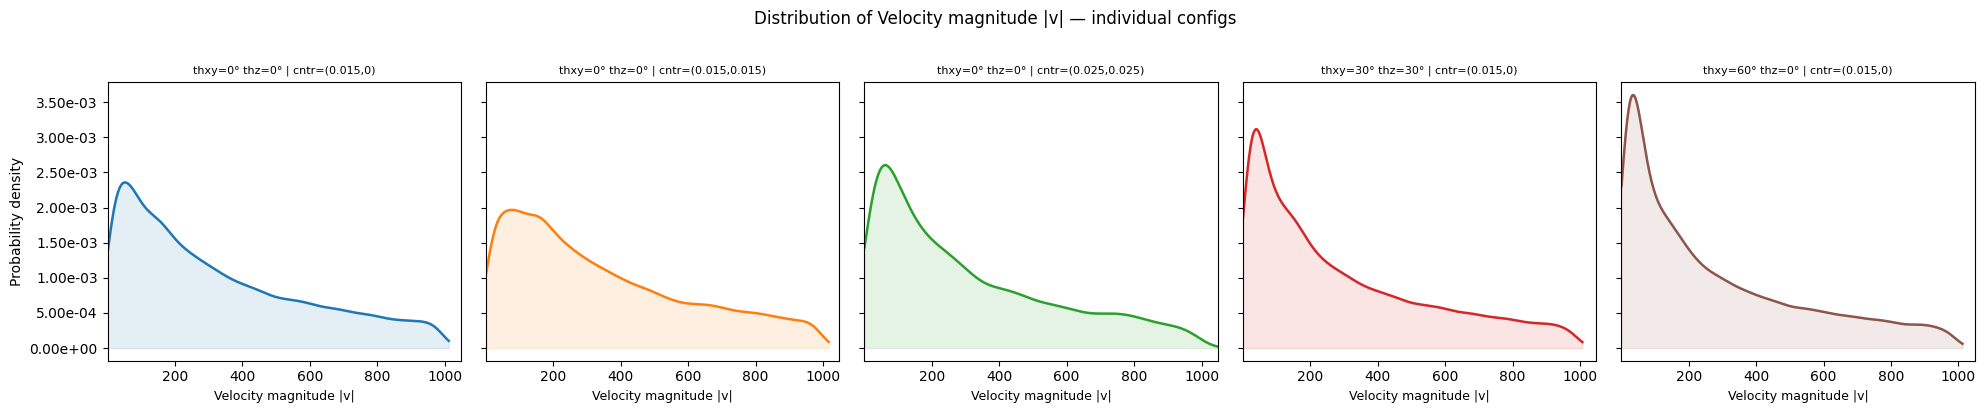

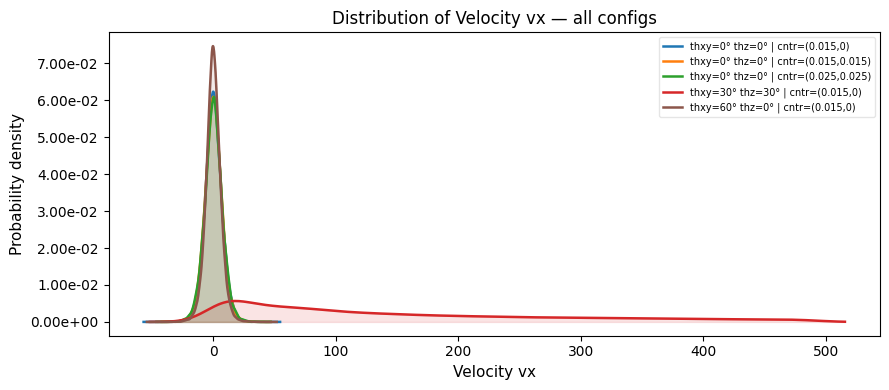

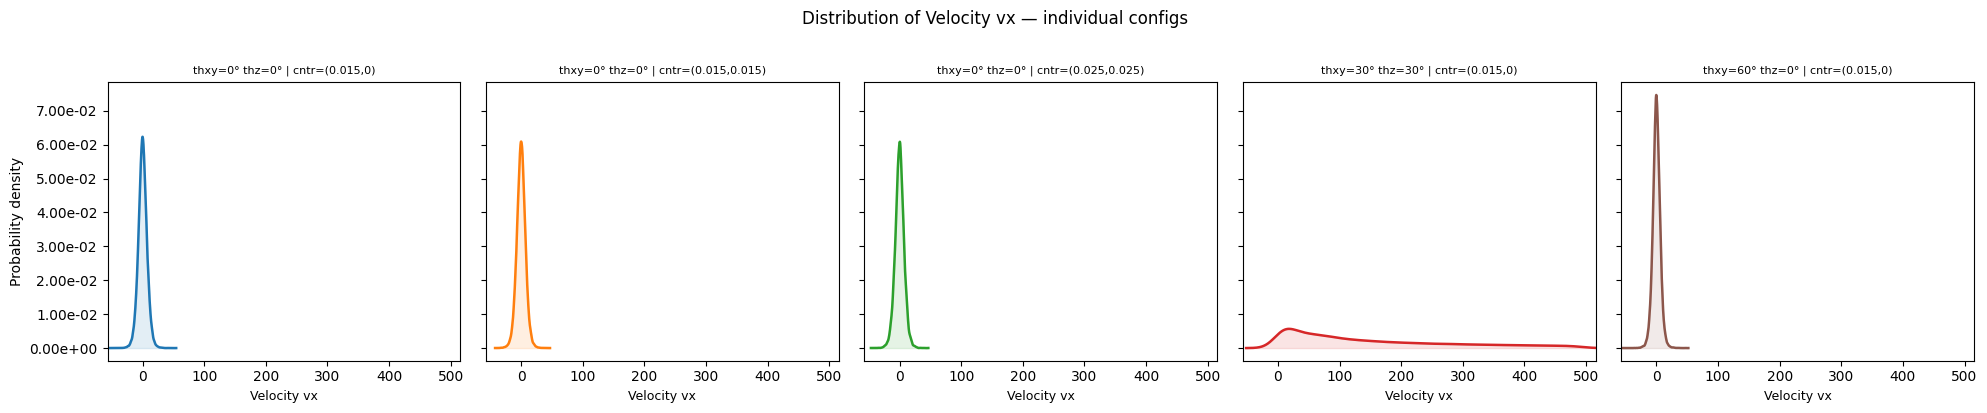

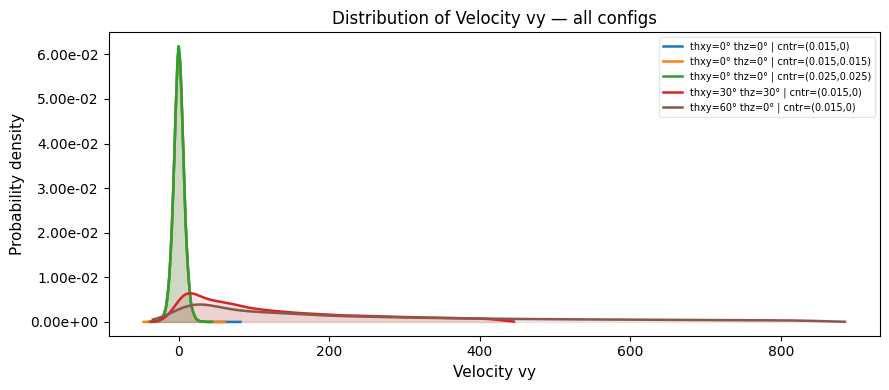

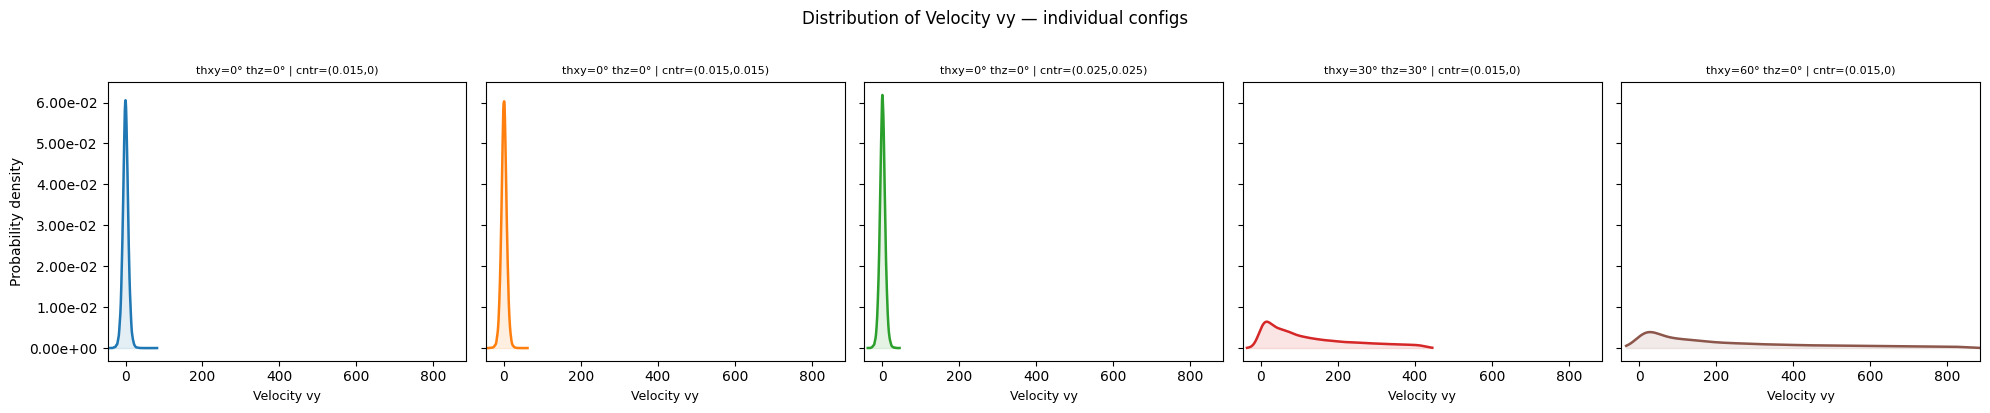

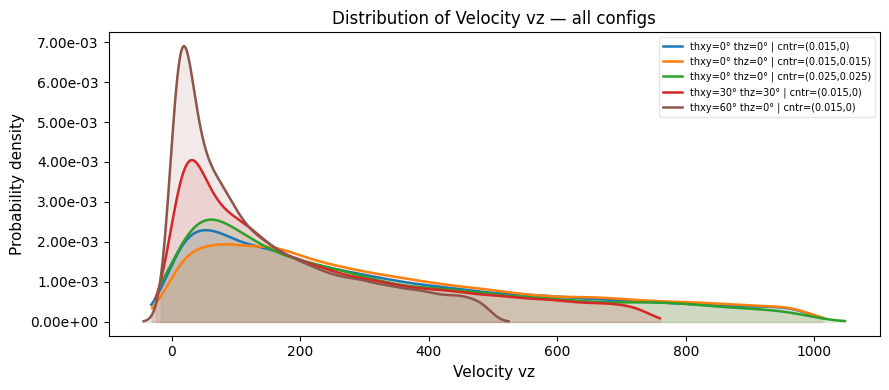

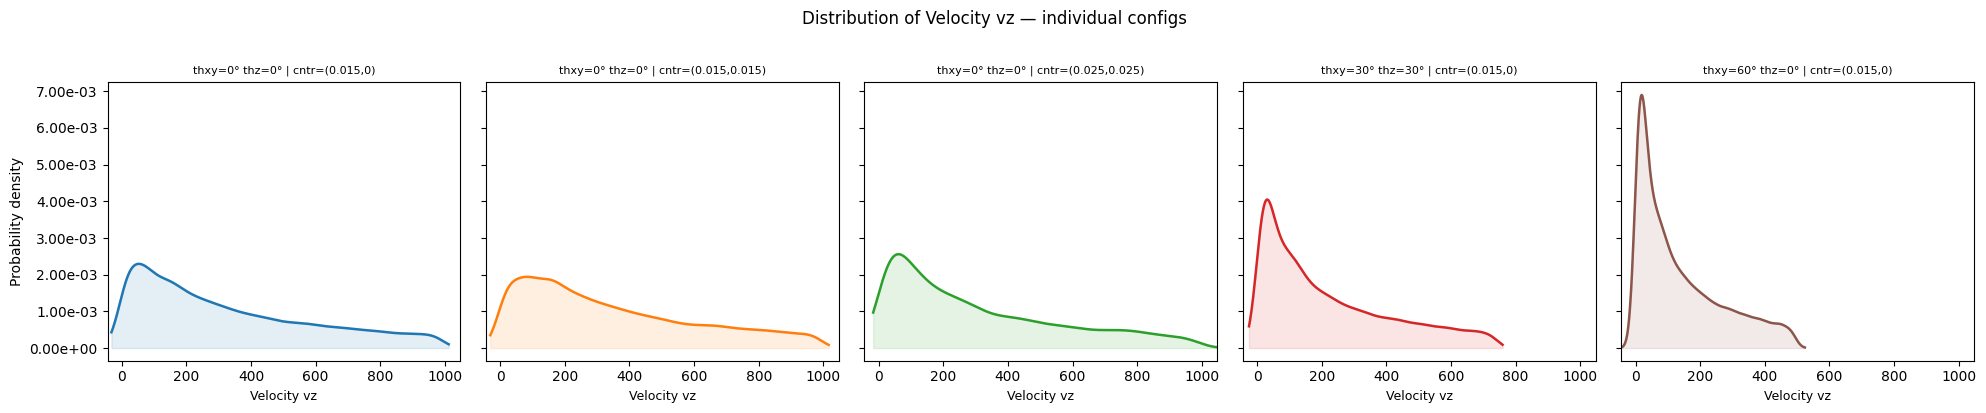

In [16]:
for key, xlabel, log_x in [
    ('mass', 'Fragment mass',          True),
    ('vmag', 'Velocity magnitude |v|', False),
    ('vx',   'Velocity vx',           False),
    ('vy',   'Velocity vy',           False),
    ('vz',   'Velocity vz',           False),
]:
    plot_kde_combined(fragment_data, LABELS, COLORS, key, xlabel, log_x)
    plot_kde_individual(fragment_data, LABELS, COLORS, key, xlabel, log_x)

## 5 - Scatter plot: velocity magnitude vs fragment mass

In [17]:
def scatter_vmag_vs_mass(frag_data, labels, colors, title_suffix='', ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    for label, color in zip(labels, colors):
        fd = frag_data[label]
        ax.scatter(fd['mass'], fd['vmag'], s=10, alpha=0.5,
                   color=color, label=label, linewidths=0)
    ax.set_xscale('log')
    ax.set_xlabel('Fragment mass', fontsize=10)
    ax.set_ylabel('Velocity magnitude |v|', fontsize=10)
    ax.set_title(f'|v| vs mass{title_suffix}', fontsize=11)
    if standalone:
        ax.legend(fontsize=7, framealpha=0.5)
        plt.tight_layout()
        plt.show()

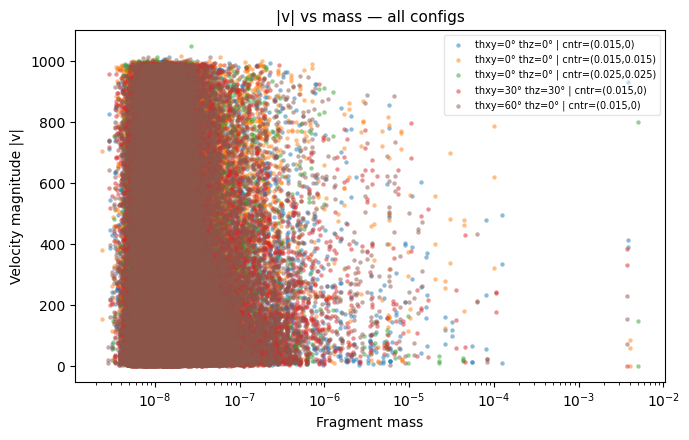

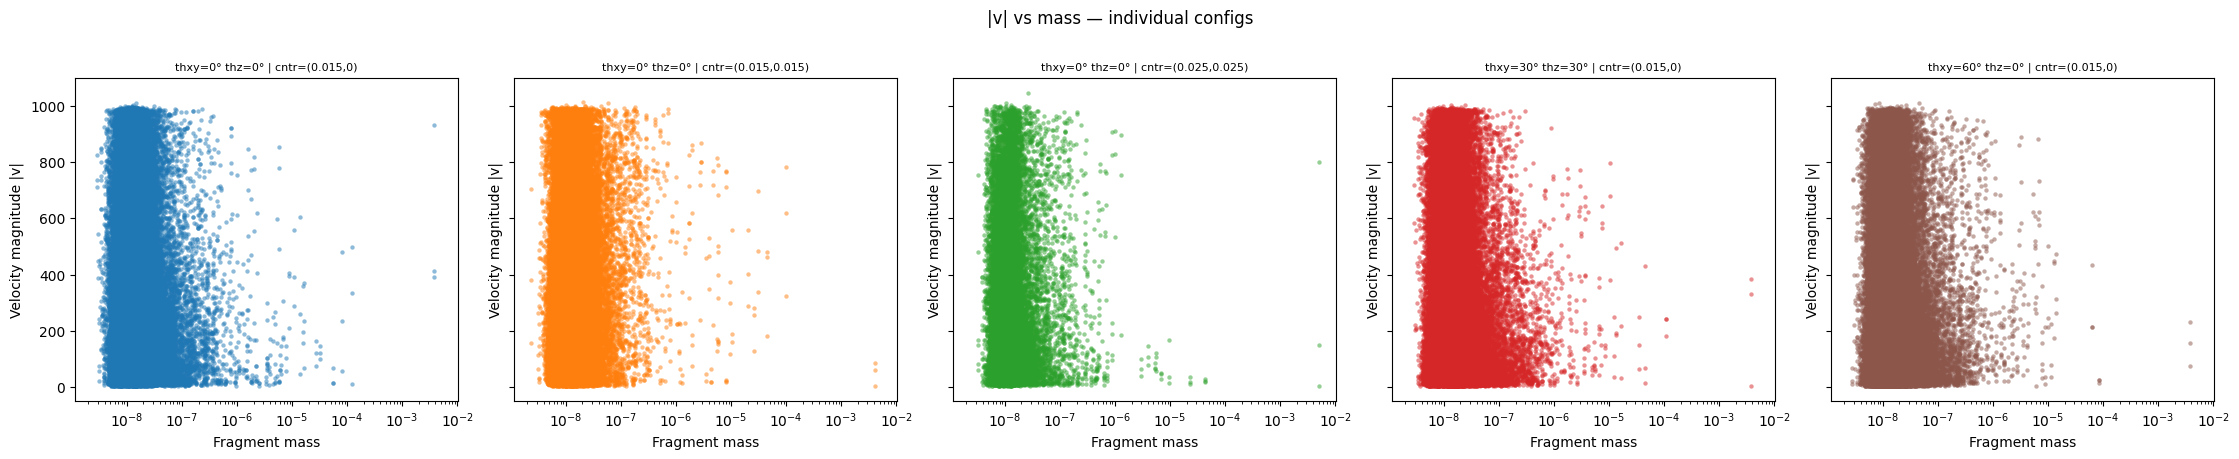

In [ ]:
scatter_vmag_vs_mass(fragment_data, LABELS, COLORS, title_suffix=' — all configs')

n = len(LABELS)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5), sharey=True, sharex=True)
for ax, label, color in zip(axes, LABELS, COLORS):
    scatter_vmag_vs_mass(
        fragment_data, [label], [color],
        title_suffix=f'\n{label}', ax=ax
    )
    ax.set_title(label, fontsize=8)
axes[0].set_ylabel('Velocity magnitude |v|', fontsize=10)
fig.suptitle('|v| vs mass — individual configs', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()